## 2. Classification of FMV: woody and non-woody

This notebook implements the second stage of the FMV workflow:

a) load a trained binary FMV segmentation model

b) predict an FMV mask from the image

c) train a multiclass U-Net only on reference FMV pixels

d) classify FMV as **non-woody** or **woody**

e) final prediction outside the predicted FMV mask to background

Note: `0`: background; `1`: non-woody FMV (original shrub and herb classes combined); `2`: woody FMV

#### A key methodological correction is that predicted segmentation masks are **not used to delete reference FMV labels before classifier training**. Doing that would discard all training pixels missed by the segmentation model. The predicted FMV mask is instead applied to the final class prediction, where it belongs in a two-stage pipeline

#### Author's detail:

Satya Prakash, Michael Wachendorf, Sunil Nautiyal, Jayan Wijesingha

Section of Grassland Science and Renewable Plant Resources, Faculty of Organic Agricultural Sciences,

University of Kassel, Steinstraße 19, D-37213 Witzenhausen Germany

For any query: satyaprakash724.sp@gmail.com; satya.prakash@uni-kassel.de


In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
import segmentation_models as sm
import albumentations as A
import keras.backend as K

2026-08-14 14:12:40.862158: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-14 14:12:41.489417: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/lib64
2026-08-14 14:12:41.489495: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64:/usr/local/cuda-11.2/extras/CUPTI/

Segmentation Models: using `keras` framework.


/home/pc4dl/venv/dlgpu/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
output_dir="/home/pc4dl/satya/Model_development/Output10082026"

In [3]:
# Set common parameters
n_classes = 1
activation = 'sigmoid'
LR = 5e-4
batch_size = 8
epochs = 50
optim = keras.optimizers.Adam(LR)

2026-08-14 14:12:43.027057: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 14:12:43.027264: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 14:12:43.035246: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 14:12:43.035524: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-08-14 14:12:43.035736: I tensorflow/compiler/xla/stream_executo

In [4]:
def weighted_dice_loss(weights):
    def loss(y_true, y_pred):
        # Ensure y_true and y_pred are float32 tensors
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Apply class weights
        # Multiply each class in y_true and y_pred by its corresponding weight
        weighted_y_true = y_true * weights
        weighted_y_pred = y_pred * weights
        
        # Flatten the tensors for Dice Loss calculation
        y_true_f = tf.keras.backend.flatten(weighted_y_true)
        y_pred_f = tf.keras.backend.flatten(weighted_y_pred)
        
        # Calculate intersection and union
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        sum_ = tf.reduce_sum(y_true_f + y_pred_f)
        
        # Compute Dice Loss
        dice_loss = 1 - (2. * intersection + 1e-7) / (sum_ + 1e-7)
        return dice_loss
    return loss

In [5]:
# Define custom loss and metrics
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss()
total_loss = dice_loss + focal_loss

metrics = [
    sm.metrics.IOUScore(threshold=0.5),
    sm.metrics.FScore(threshold=0.5),
]

In [6]:
# Function to One-Hot Encode Labels
def one_hot_encode(mask, num_classes):
    one_hot = np.zeros((mask.shape[0], mask.shape[1], num_classes), dtype=np.uint8)
    for i in range(num_classes):
        one_hot[:, :, i] = (mask == i).astype(np.uint8)
    return one_hot

In [7]:
def batch_one_hot_encode(masks, num_classes):
    batch, h, w = masks.shape
    one_hot = np.zeros((batch, h, w, num_classes), dtype=np.float32)  # <-- use float32
    for i in range(num_classes):
        one_hot[..., i] = (masks == i).astype(np.float32)
    return one_hot

In [8]:
# --- Merge Shrubs and Herbs (Class 1 and 2 into Class 1) ---
def merge_shrubs_herbs(mask):
    merged_mask = np.copy(mask)
    merged_mask[merged_mask == 2] = 1  # Merge class 2 into class 1
    merged_mask[merged_mask == 3] = 2  # Shift class 3 to class 2
    return merged_mask

In [9]:
# --- Load Images and Masks (for classification) ---
def load_images_and_multiclass_masks(image_dir, mask_dir, bands=[6, 4, 1], num_classes=3, augmentations=None):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        with rasterio.open(img_path) as src:
            img = np.stack([src.read(b) for b in bands], axis=-1)
        img = np.clip(img, 0, np.percentile(img, 99)).astype('float32')

        with rasterio.open(mask_path) as src:
            mask = src.read(1)

        mask = merge_shrubs_herbs(mask)
        mask = one_hot_encode(mask, num_classes)

        if augmentations:
            augmented = augmentations(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']

        images.append(img)
        masks.append(mask)

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

In [10]:
# --- FMV Mask Application ---
def apply_fmv_mask(labels, fmv_mask):
    fmv_mask_bin = (fmv_mask > 0.5).astype(np.uint8)
    label_class = np.argmax(labels, axis=-1)
    masked = np.where(fmv_mask_bin == 1, label_class, 0)
    return masked

In [11]:
# --- Custom Masked Loss ---
def masked_categorical_focal_loss(y_true, y_pred):
    loss_fn = sm.losses.CategoricalFocalLoss()
    valid_mask = tf.reduce_sum(y_true[..., 1:], axis=-1) > 0
    y_true_flat = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
    y_pred_flat = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
    valid_mask_flat = tf.reshape(valid_mask, [-1])
    y_true_masked = tf.boolean_mask(y_true_flat, valid_mask_flat)
    y_pred_masked = tf.boolean_mask(y_pred_flat, valid_mask_flat)
    return loss_fn(y_true_masked, y_pred_masked)

In [12]:
# --- Custom Accuracy Metric ---
def masked_accuracy(y_true, y_pred):
    y_pred_cls = tf.argmax(y_pred, axis=-1)
    y_true_cls = tf.argmax(y_true, axis=-1)
    valid_mask = tf.cast(y_true_cls > 0, tf.float32)
    correct = tf.cast(tf.equal(y_true_cls, y_pred_cls), tf.float32)
    return tf.reduce_sum(correct * valid_mask) / (tf.reduce_sum(valid_mask) + K.epsilon())

In [13]:
# Define backbone and preprocessing function
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

In [14]:
# Define the model
model = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation=activation)

# Compile the model
weights = tf.constant([0.052, 0.948])  # Weights for two classes (e.g., background, object)
#weights = tf.constant([0.1, 0.9])  # Weights for two classes (e.g., background, object)
# Create a custom loss that combines Dice and Focal Loss
weighted_dice = weighted_dice_loss(weights)
focal_loss = sm.losses.BinaryFocalLoss()

total_loss = lambda y_true, y_pred: weighted_dice(y_true, y_pred) + focal_loss(y_true, y_pred)

model.compile(optimizer=optim, loss=total_loss, metrics=metrics)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',    # Monitor validation loss
    patience=10,           # Number of epochs with no improvement after which training will stop
    restore_best_weights=True  # Restore model weights from the epoch with the best validation loss
)

# Print model summary
print(model.summary())

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 bn_data (BatchNormalization)   (None, None, None,   9           ['data[0][0]']                   
                                3)                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, None, None,   0          ['bn_data[0][0]']                
                                3)                                                          

In [15]:
# Load trained FMV segmentation model
fmv_model = tf.keras.models.load_model("UNET_resnet34_641.h5", compile=False)

In [16]:
def predict_fmv_mask(model, images):
    pred = model.predict(images)
    return (pred > 0.5).astype(np.uint8).squeeze(-1)

In [17]:
def apply_fmv_to_labels(y_onehot, fmv_mask, num_classes):
    y_cls = np.argmax(y_onehot, axis=-1)
    y_masked = np.where(fmv_mask == 1, y_cls, 0)
    return batch_one_hot_encode(y_masked, num_classes)

### Training data for FMV classification

In [18]:
# --- Paths ---
base_dir = "/home/pc4dl/satya/Model_development/Sample3_classification"
train_image_dir = os.path.join(base_dir, 'Training', 'Image')
train_mask_dir = os.path.join(base_dir, 'Training', 'labels')
val_image_dir = os.path.join(base_dir, 'Validation', 'Image')
val_mask_dir = os.path.join(base_dir, 'Validation', 'labels')
test_image_dir = os.path.join(base_dir, 'Testing_Transition', 'Image')
test_mask_dir = os.path.join(base_dir, 'Testing_Transition', 'labels')

In [19]:
# --- Load Data ---
X_train1, y_train1 = load_images_and_multiclass_masks(train_image_dir, train_mask_dir, num_classes=3)
X_val1, y_val1 = load_images_and_multiclass_masks(val_image_dir, val_mask_dir, num_classes=3)
X_test1, y_test1 = load_images_and_multiclass_masks(test_image_dir, test_mask_dir, num_classes=3)

In [20]:
# LOAD & APPLY FMV SEGMENTATION MODEL
print("Loading FMV segmentation model...")
fmv_model = tf.keras.models.load_model("UNET_resnet34_641.h5", compile=False)

Loading FMV segmentation model...


In [21]:
# --- Simulate FMV Mask Prediction (Replace with actual segmentation model output) ---
fmv_mask_train = np.max(y_train1[..., 1:], axis=-1)
fmv_mask_val = np.max(y_val1[..., 1:], axis=-1)
fmv_mask_test = np.max(y_test1[..., 1:], axis=-1)

In [22]:
print("Predicting FMV masks...")
fmv_mask_train = predict_fmv_mask(fmv_model, X_train1)
fmv_mask_val = predict_fmv_mask(fmv_model, X_val1)
fmv_mask_test = predict_fmv_mask(fmv_model, X_test1)

Predicting FMV masks...


2026-08-14 14:13:01.807665: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100


5/5 [==============================] - 0s 22ms/step


In [23]:
# --- Apply FMV Mask ---
y_train_masked = apply_fmv_to_labels(y_train1, fmv_mask_train, num_classes=3)
y_val_masked = apply_fmv_to_labels(y_val1, fmv_mask_val, num_classes=3)
y_test_masked = apply_fmv_to_labels(y_test1, fmv_mask_test, num_classes=3)

In [24]:
# --- Model Setup for FMV classification ---
BACKBONE = 'resnet34'
n_classes = 3
activation = 'softmax'
model = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation=activation)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=masked_categorical_focal_loss,
    metrics=[masked_accuracy]
)
# Print model summary
print(model.summary())

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 bn_data (BatchNormalization)   (None, None, None,   9           ['data[0][0]']                   
                                3)                                                                
                                                                                                  
 zero_padding2d_34 (ZeroPadding  (None, None, None,   0          ['bn_data[0][0]']                
 2D)                            3)                                                          

In [25]:
#Load Model
from tensorflow.keras.models import load_model

# Load the model
model = load_model(
    'unet_FMVmodel_classification16082025Trans.h5',
    custom_objects={
        'masked_categorical_focal_loss': masked_categorical_focal_loss,
        'masked_accuracy': masked_accuracy
    }
)
print("Model loaded and recompiled successfully!")

Model loaded and recompiled successfully!


### Testing Transition test dataset

In [26]:
# --- Evaluation ---
loss, acc = model.evaluate(X_test1, y_test1)
print(f"Test Loss: {loss:.4f}, Test Accuracy (masked): {acc:.4f}")

5/5 [==============================] - 1s 40ms/step - loss: 0.0087 - masked_accuracy: 0.8689
Test Loss: 0.0087, Test Accuracy (masked): 0.8689


In [27]:
# --- Detailed Metrics ---
y_pred = model.predict(X_test1)
y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
y_true_labels = np.argmax(y_test1, axis=-1).flatten()

5/5 [==============================] - 1s 29ms/step


In [28]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
mask = y_true_labels > 0  # Ignore background
print("\nClassification Report (FMV only):")
print(classification_report(y_true_labels[mask], y_pred_labels[mask], digits=4))


Classification Report (FMV only):
              precision    recall  f1-score   support

           1     0.7874    0.8250    0.8058     26154
           2     0.9183    0.8982    0.9082     57266

    accuracy                         0.8753     83420
   macro avg     0.8528    0.8616    0.8570     83420
weighted avg     0.8773    0.8753    0.8761     83420



In [29]:
test_image_dir_trans = os.path.join(base_dir, 'Testing_Transition', 'Image')
test_mask_dir_trans = os.path.join(base_dir, 'Testing_Transition', 'labels')

In [30]:
X_test_trans, y_test_trans = load_images_and_multiclass_masks(test_image_dir_trans, test_mask_dir_trans, num_classes=3)

In [31]:
# --- Simulate FMV Mask for Transition Test ---
fmv_mask_test_trans = np.max(y_test_trans[..., 1:], axis=-1)

In [32]:
# --- Apply FMV Mask ---
y_test_trans_masked = apply_fmv_mask(y_test_trans, fmv_mask_test_trans)

In [33]:
# --- Re-encode Masked Labels ---
y_test_trans_encoded = batch_one_hot_encode(y_test_trans_masked, 3)

In [34]:
# --- Evaluate on Transition Test Set ---
loss_trans, acc_trans = model.evaluate(X_test_trans, y_test_trans_encoded)
print(f"\n[Transition Test] Loss: {loss_trans:.4f}, Accuracy (masked): {acc_trans:.4f}")

# --- Prediction and Metrics for Transition Test ---
y_pred_trans = model.predict(X_test_trans)
y_pred_labels_trans = np.argmax(y_pred_trans, axis=-1).flatten()
y_true_labels_trans = np.argmax(y_test_trans_encoded, axis=-1).flatten()

# --- Filter out background (class 0) ---
mask_trans = y_true_labels_trans > 0

from sklearn.metrics import classification_report
print("\n[Transition Test] Classification Report (FMV only):")
print(classification_report(y_true_labels_trans[mask_trans], y_pred_labels_trans[mask_trans], digits=4))

5/5 [==============================] - 0s 30ms/step - loss: 0.0087 - masked_accuracy: 0.8689

[Transition Test] Loss: 0.0087, Accuracy (masked): 0.8689
5/5 [==============================] - 0s 27ms/step

[Transition Test] Classification Report (FMV only):
              precision    recall  f1-score   support

           1     0.7874    0.8250    0.8058     26154
           2     0.9183    0.8982    0.9082     57266

    accuracy                         0.8753     83420
   macro avg     0.8528    0.8616    0.8570     83420
weighted avg     0.8773    0.8753    0.8761     83420



In [35]:
def compute_f1_per_class(
    true_mask,
    predicted_mask,
    num_classes=3
):
    """
    Classes:
        0 = Background
        1 = Non-woody FMV
        2 = Woody FMV

    Returns:
        [Non-woody F1, Woody F1]
    """

    true_flat = np.asarray(true_mask).flatten()
    predicted_flat = np.asarray(predicted_mask).flatten()

    return f1_score(
        true_flat,
        predicted_flat,
        labels=list(range(1, num_classes)),
        average=None,
        zero_division=0
    )

In [36]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_test_results_with_f1(model, X_test, y_test, fmv_mask, num_classes=3,
                               output_dir="/home/pc4dl/satya/Model_development/Output10082026_CT"):
    
    os.makedirs(output_dir, exist_ok=True)

    y_pred_test = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred_test, axis=-1)
    y_test_labels = np.argmax(y_test, axis=-1)

    num_samples = X_test.shape[0]

    for i in range(num_samples):
        fig, axs = plt.subplots(1, 4, figsize=(15, 5))

        # Image normalization
        img = X_test[i][:, :, :3]
        img = (img - img.min()) / (img.max() - img.min())
        img = (img * 255).astype(np.uint8)

        axs[0].imshow(img)
        axs[0].set_title("Original Image")
        axs[0].axis("off")

        # Custom colormap
        custom_cmap = ListedColormap(["#0B1A3D", "#FF00C5", "#3BBD3A"])

        axs[1].imshow(y_test_labels[i], cmap=custom_cmap, vmin=0, vmax=2)
        axs[1].set_title("Ground Truth Mask")
        axs[1].axis("off")

        masked_pred = np.where(fmv_mask[i] == 1, y_pred_labels[i], 0)
        axs[2].imshow(masked_pred, cmap=custom_cmap, vmin=0, vmax=2)
        axs[2].set_title("Predicted Mask")
        axs[2].axis("off")

        masked_true = np.where(fmv_mask[i] == 1, y_test_labels[i], 0)
        f1_scores = compute_f1_per_class(masked_true, masked_pred, num_classes)

        # F1 score text
        class_names = ["Non-Woody Plant", "Woody Plant"]
        class_colors = ["#FF00C5", "#3BBD3A"]
        f1_text = "\n".join([f"{name}: {score:.2f}" for name, score in zip(class_names, f1_scores)])

        axs[3].text(0.05, 0.85, "F1-Score Per Class\n" + f1_text,
                    fontsize=12,
                    verticalalignment='top',
                    horizontalalignment='left',
                    transform=axs[3].transAxes,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='white', boxstyle='round,pad=0.5'))

        legend_patches = [mpatches.Patch(color=color, label=name)
                          for color, name in zip(class_colors, class_names)]
        axs[3].legend(handles=legend_patches, loc='center left', fontsize=12, frameon=False)
        axs[3].axis("off")

        # Save figure
        filename = f"sample_{i}.png"
        filepath = os.path.join(output_dir, filename)
        print(f"Saving: {filepath}")
        plt.savefig(filepath, bbox_inches='tight')
        plt.close(fig)  # Important to avoid memory overload

    print(f"\n✅ All figures saved to: {output_dir}")
plot_test_results_with_f1(model, X_test1, y_test1, fmv_mask_test, num_classes=3)

5/5 [==============================] - 0s 25ms/step
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_0.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_1.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_2.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_3.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_4.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_5.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_6.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_7.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_8.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_9.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_10.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_CT/sample_11.png
Saving: /home/pc4dl/satya/Model_development/Ou

#### Making plot

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
y_pred = model.predict(X_test1, verbose=1)
# Initialize lists for per-chip metrics
precision_class1 = []
precision_class2 = []
recall_class1 = []
recall_class2 = []
f1_class1 = []
f1_class2 = []

# For pixel-weighted means
weighted_prec1_sum = 0
weighted_prec2_sum = 0
weighted_recall1_sum = 0
weighted_recall2_sum = 0
weighted_f1_1_sum = 0
weighted_f1_2_sum = 0
pixel_count_total = 0

# --- Loop over test chips ---
for y_true_chip, y_pred_chip in zip(y_test1, y_pred):
    y_true_flat = np.argmax(y_true_chip, axis=-1).flatten()
    y_pred_flat = np.argmax(y_pred_chip, axis=-1).flatten()

    valid = y_true_flat > 0
    y_true_valid = y_true_flat[valid]
    y_pred_valid = y_pred_flat[valid]

    if len(y_true_valid) == 0:
        precision_class1.append(0)
        precision_class2.append(0)
        recall_class1.append(0)
        recall_class2.append(0)
        f1_class1.append(0)
        f1_class2.append(0)
        continue

    # --- Per-chip metrics ---
    prec = precision_score(y_true_valid, y_pred_valid, average=None, labels=[1, 2], zero_division=0)
    rec = recall_score(y_true_valid, y_pred_valid, average=None, labels=[1, 2], zero_division=0)
    f1 = f1_score(y_true_valid, y_pred_valid, average=None, labels=[1, 2], zero_division=0)

    precision_class1.append(prec[0])
    precision_class2.append(prec[1])
    recall_class1.append(rec[0])
    recall_class2.append(rec[1])
    f1_class1.append(f1[0])
    f1_class2.append(f1[1])

    # --- Pixel-weighted global sums ---
    n_pixels = len(y_true_valid)
    pixel_count_total += n_pixels
    weighted_prec1_sum += prec[0] * n_pixels
    weighted_prec2_sum += prec[1] * n_pixels
    weighted_recall1_sum += rec[0] * n_pixels
    weighted_recall2_sum += rec[1] * n_pixels
    weighted_f1_1_sum += f1[0] * n_pixels
    weighted_f1_2_sum += f1[1] * n_pixels

# --- Final pixel-weighted global means ---
global_precision_class1 = weighted_prec1_sum / pixel_count_total
global_precision_class2 = weighted_prec2_sum / pixel_count_total
global_recall_class1 = weighted_recall1_sum / pixel_count_total
global_recall_class2 = weighted_recall2_sum / pixel_count_total
global_f1_class1 = weighted_f1_1_sum / pixel_count_total
global_f1_class2 = weighted_f1_2_sum / pixel_count_total

print("(Pixel-weighted) Averages:")
print(f"Non-Woody Plant - Precision: {global_precision_class1:.2f}, Recall: {global_recall_class1:.2f}, F1: {global_f1_class1:.2f}")
print(f"Woody Plant     - Precision: {global_precision_class2:.2f}, Recall: {global_recall_class2:.2f}, F1: {global_f1_class2:.2f}")

5/5 [==============================] - 0s 29ms/step
(Pixel-weighted) Averages:
Non-Woody Plant - Precision: 0.70, Recall: 0.67, F1: 0.66
Woody Plant     - Precision: 0.86, Recall: 0.85, F1: 0.84


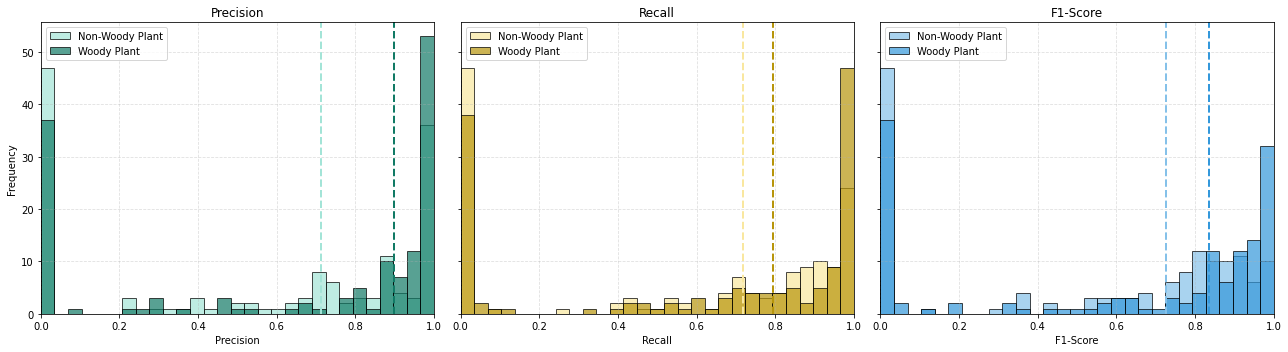

In [38]:
# --- Custom color palette ---
metric_colors = {
    "Non-Woody Plant": {
        "Precision": "#A3E4D7",  # mint
        "Recall": "#F9E79F",     # light yellow
        "F1-Score": "#85C1E9"    # light blue
    },
    "Woody Plant": {
        "Precision": "#117A65",  # dark teal
        "Recall": "#B7950B",     # gold brown
        "F1-Score": "#3498DB"    # dark blue
    },
}

# --- Metric data for plotting ---
metrics_data = {
    "Precision": (precision_class1, precision_class2, global_precision_class1, global_precision_class2),
    "Recall": (recall_class1, recall_class2, global_recall_class1, global_recall_class2),
    "F1-Score": (f1_class1, f1_class2, global_f1_class1, global_f1_class2),
}

# --- Plot histograms ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (metric_name, (class1_data, class2_data, global1, global2)) in zip(axs, metrics_data.items()):
    bins = np.linspace(0, 1, 30)

    # Plot histograms
    ax.hist(class1_data, bins=bins, alpha=0.7, label="Non-Woody Plant",
            color=metric_colors["Non-Woody Plant"][metric_name], edgecolor='black')
    ax.hist(class2_data, bins=bins, alpha=0.7, label="Woody Plant",
            color=metric_colors["Woody Plant"][metric_name], edgecolor='black')

    # Plot per-chip medians
    ax.axvline(np.median(class1_data), color=metric_colors["Non-Woody Plant"][metric_name],
               linestyle='--', linewidth=2)
    ax.axvline(np.median(class2_data), color=metric_colors["Woody Plant"][metric_name],
               linestyle='--', linewidth=2)

    # Annotate pixel-weighted global values
    ymax = ax.get_ylim()[1]

    ax.set_title(metric_name)
    ax.set_xlabel(metric_name)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.4)
    if metric_name == "Precision":
        ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
output_dir="/home/pc4dl/satya/Model_development/Output10082026_CT"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(
    output_dir,
    "Transition_precision_recall_f1_histograms.png"
)
plt.savefig(plot_path, dpi=600, bbox_inches="tight", facecolor="white")

plt.show()

## Testing Rural test datset

In [48]:
test_image_dir_rural = os.path.join(base_dir, 'Testing', 'Image')
test_mask_dir_rural = os.path.join(base_dir, 'Testing', 'labels')

In [49]:
# --- Load the rural test images and multiclass labels ---
X_test_rural, y_test_rural = load_images_and_multiclass_masks(test_image_dir_rural, test_mask_dir_rural, num_classes=3)

print("Rural test images:", X_test_rural.shape)
print("Rural test labels:", y_test_rural.shape)

Rural test images: (144, 128, 128, 3)
Rural test labels: (144, 128, 128, 3)


In [50]:
fmv_mask_test_rural = predict_fmv_mask(fmv_model, X_test_rural)

5/5 [==============================] - 0s 27ms/step


In [51]:
fmv_mask_true_rural = np.max(y_test_rural[..., 1:], axis=-1).astype(np.uint8)
print("Predicted rural FMV-mask shape:", fmv_mask_test_rural.shape)
print("True rural FMV-mask shape:", fmv_mask_true_rural.shape)

Predicted rural FMV-mask shape: (144, 128, 128)
True rural FMV-mask shape: (144, 128, 128)


In [52]:
loss_rural, acc_rural = model.evaluate(X_test_rural, y_test_rural, verbose=1)

print(f"\n[Rural Test - classification only] " f"Loss: {loss_rural:.4f}, Accuracy (masked): {acc_rural:.4f}")

5/5 [==============================] - 0s 32ms/step - loss: 0.0104 - masked_accuracy: 0.8512

[Rural Test - classification only] Loss: 0.0104, Accuracy (masked): 0.8512


In [53]:
from sklearn.metrics import classification_report, confusion_matrix

# --- Predict woody/non-woody classes ---
y_pred_rural_prob = model.predict(X_test_rural, verbose=1)
y_pred_rural_raw = np.argmax(y_pred_rural_prob, axis=-1)
y_true_rural = np.argmax(y_test_rural, axis=-1)

5/5 [==============================] - 0s 30ms/step


In [54]:
true_fmv_pixels_rural = y_true_rural > 0
print("\n[Rural Test] Classification Report (true FMV pixels only):")
print(
    classification_report(
        y_true_rural[true_fmv_pixels_rural],
        y_pred_rural_raw[true_fmv_pixels_rural],
        labels=[1, 2],
        target_names=["Non-woody FMV", "Woody FMV"],
        digits=4,
        zero_division=0
    )
)

print("[Rural Test] Confusion Matrix (true FMV pixels only):")
print(
    confusion_matrix(
        y_true_rural[true_fmv_pixels_rural],
        y_pred_rural_raw[true_fmv_pixels_rural],
        labels=[1, 2]
    )
)


[Rural Test] Classification Report (true FMV pixels only):
               precision    recall  f1-score   support

Non-woody FMV     0.5364    0.8465    0.6567     26054
    Woody FMV     0.9682    0.8647    0.9135    140872

     accuracy                         0.8618    166926
    macro avg     0.7523    0.8556    0.7851    166926
 weighted avg     0.9008    0.8618    0.8734    166926

[Rural Test] Confusion Matrix (true FMV pixels only):
[[ 22054   4000]
 [ 19061 121811]]


In [46]:
# --- Save rural image-level results ---
rural_output_dir = "/home/pc4dl/satya/Model_development/Output10082026_Rural"

plot_test_results_with_f1(
    model=model,
    X_test=X_test_rural,
    y_test=y_test_rural,
    fmv_mask=fmv_mask_test_rural,
    num_classes=3,
    output_dir=rural_output_dir
)

5/5 [==============================] - 0s 24ms/step
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_0.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_1.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_2.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_3.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_4.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_5.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_6.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_7.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_8.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_9.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_10.png
Saving: /home/pc4dl/satya/Model_development/Output10082026_Rural/sample_11.png
Saving: /h

In [58]:
import pandas as pd
rural_chip_metrics = []

for chip_id, (y_true_chip, y_pred_chip) in enumerate(
    zip(y_true_rural, y_pred_rural_raw)
):
    y_true_flat = y_true_chip.flatten()
    y_pred_flat = y_pred_chip.flatten()

    valid = y_true_flat > 0

    if not np.any(valid):
        continue

    precision = precision_score(
        y_true_flat[valid],
        y_pred_flat[valid],
        labels=[1, 2],
        average=None,
        zero_division=0
    )

    recall = recall_score(
        y_true_flat[valid],
        y_pred_flat[valid],
        labels=[1, 2],
        average=None,
        zero_division=0
    )

    f1 = f1_score(
        y_true_flat[valid],
        y_pred_flat[valid],
        labels=[1, 2],
        average=None,
        zero_division=0
    )

    for class_id, class_name, j in [
        (1, "Non-woody FMV", 0),
        (2, "Woody FMV", 1)
    ]:
        rural_chip_metrics.append({
            "chip_id": chip_id,
            "class_id": class_id,
            "class_name": class_name,
            "precision": precision[j],
            "recall": recall[j],
            "f1_score": f1[j],
            "n_true_fmv_pixels": int(np.sum(valid))
        })


# Place it here: after both loops are finished
rural_chip_metrics_df = pd.DataFrame(rural_chip_metrics)


Rural global classification metrics:
Non-Woody Plant - Precision: 0.54, Recall: 0.85, F1: 0.66
Woody Plant     - Precision: 0.97, Recall: 0.86, F1: 0.91


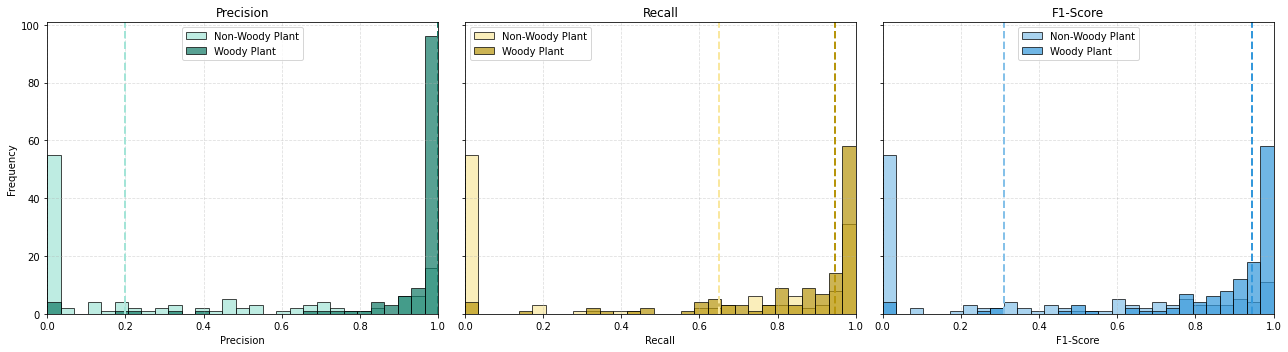

Rural histogram saved to: /home/pc4dl/satya/Model_development/Output10082026_Rural/rural_metric_histograms_same_style.png


In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. Extract rural per-chip metrics
# ============================================================

nonwoody_rural = rural_chip_metrics_df[
    rural_chip_metrics_df["class_name"] == "Non-woody FMV"
]

woody_rural = rural_chip_metrics_df[
    rural_chip_metrics_df["class_name"] == "Woody FMV"
]


# Non-woody FMV per-chip metrics
precision_class1 = nonwoody_rural["precision"].to_numpy()
recall_class1 = nonwoody_rural["recall"].to_numpy()
f1_class1 = nonwoody_rural["f1_score"].to_numpy()


# Woody FMV per-chip metrics
precision_class2 = woody_rural["precision"].to_numpy()
recall_class2 = woody_rural["recall"].to_numpy()
f1_class2 = woody_rural["f1_score"].to_numpy()


# ============================================================
# 2. Calculate global rural metrics
# ============================================================

y_true_rural_flat = y_true_rural.flatten()
y_pred_rural_flat = y_pred_rural_raw.flatten()

# Classification-only evaluation:
# include only true FMV pixels
valid_rural = y_true_rural_flat > 0

global_precision = precision_score(
    y_true_rural_flat[valid_rural],
    y_pred_rural_flat[valid_rural],
    labels=[1, 2],
    average=None,
    zero_division=0
)

global_recall = recall_score(
    y_true_rural_flat[valid_rural],
    y_pred_rural_flat[valid_rural],
    labels=[1, 2],
    average=None,
    zero_division=0
)

global_f1 = f1_score(
    y_true_rural_flat[valid_rural],
    y_pred_rural_flat[valid_rural],
    labels=[1, 2],
    average=None,
    zero_division=0
)


# Separate the two classes
global_precision_class1 = global_precision[0]
global_precision_class2 = global_precision[1]

global_recall_class1 = global_recall[0]
global_recall_class2 = global_recall[1]

global_f1_class1 = global_f1[0]
global_f1_class2 = global_f1[1]


print("\nRural global classification metrics:")

print(
    f"Non-Woody Plant - "
    f"Precision: {global_precision_class1:.2f}, "
    f"Recall: {global_recall_class1:.2f}, "
    f"F1: {global_f1_class1:.2f}"
)

print(
    f"Woody Plant     - "
    f"Precision: {global_precision_class2:.2f}, "
    f"Recall: {global_recall_class2:.2f}, "
    f"F1: {global_f1_class2:.2f}"
)

metric_colors = {
    "Non-Woody Plant": {
        "Precision": "#A3E4D7",  # mint
        "Recall": "#F9E79F",     # light yellow
        "F1-Score": "#85C1E9"    # light blue
    },
    "Woody Plant": {
        "Precision": "#117A65",  # dark teal
        "Recall": "#B7950B",     # gold brown
        "F1-Score": "#3498DB"    # dark blue
    }
}


metrics_data = {
    "Precision": (
        precision_class1,
        precision_class2,
        global_precision_class1,
        global_precision_class2
    ),
    "Recall": (
        recall_class1,
        recall_class2,
        global_recall_class1,
        global_recall_class2
    ),
    "F1-Score": (
        f1_class1,
        f1_class2,
        global_f1_class1,
        global_f1_class2
    )
}


# ============================================================
# 5. Plot rural histograms
# ============================================================

fig, axs = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True
)

for ax, (
    metric_name,
    (class1_data, class2_data, global1, global2)
) in zip(axs, metrics_data.items()):

    bins = np.linspace(0, 1, 30)

    # Non-woody histogram
    ax.hist(
        class1_data,
        bins=bins,
        alpha=0.7,
        label="Non-Woody Plant",
        color=metric_colors["Non-Woody Plant"][metric_name],
        edgecolor="black"
    )

    # Woody histogram
    ax.hist(
        class2_data,
        bins=bins,
        alpha=0.7,
        label="Woody Plant",
        color=metric_colors["Woody Plant"][metric_name],
        edgecolor="black"
    )

    # Non-woody per-chip median
    ax.axvline(
        np.median(class1_data),
        color=metric_colors["Non-Woody Plant"][metric_name],
        linestyle="--",
        linewidth=2
    )

    # Woody per-chip median
    ax.axvline(
        np.median(class2_data),
        color=metric_colors["Woody Plant"][metric_name],
        linestyle="--",
        linewidth=2
    )

    ax.set_title(metric_name)
    ax.set_xlabel(metric_name)
    ax.set_xlim(0, 1)
    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    if metric_name == "Precision":
        ax.set_ylabel("Frequency")

    ax.legend()


plt.tight_layout()

# Optional: save the rural plot
rural_plot_path = os.path.join(
    rural_output_dir,
    "rural_metric_histograms_same_style.png"
)

plt.savefig(
    rural_plot_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"Rural histogram saved to: {rural_plot_path}")